# 1. Can a robot work out how much to trust a camera — and would that help?

A robot drives a warehouse aisle. Its wheel odometry drifts. One ceiling camera watches
the floor and, when it finds the robot, reports where it thinks the robot is. Those
reports are not exact, and the filter needs a number for *how* inexact: the observation
noise covariance $\mathbf{R}$.

$\mathbf{R}$ is a **2×2 matrix**, not a number and not a vector: two variances and a
covariance, which together make an ellipse with a size, a shape and an orientation. This
notebook asks whether the robot could estimate that matrix from the very drive it is
filtering, using nothing but odometry and the camera. That is standard Bayesian
machinery and it works: the fitted covariance describes the recorded readings better
than the true one does.

Everything is judged against **what the camera's errors actually are on this drive**,
measured with ground truth. That reference is not something a robot could compute — it
is the best a zero-mean model could possibly be told, and it is here so that "the loop
is optimistic" can be replaced by "the loop disagrees with the truth by this much".

**Then it asks the three questions that decide whether to deploy it:**

1. Is the implementation wrong? (Two ways to check, neither of which is an argument.)
2. *Why* does it fit better?
3. Does it **predict** better — on data it was never fitted on? And predict **what**?
   The camera's next reading and the robot's true position turn out to be different
   questions with different answers.

**And it ends by fixing the problem rather than only naming it.** The answer to all three
turns on the camera having a *lean* — a displacement in the same direction every frame —
which a zero-mean covariance has no term for. The last section measures exactly how much
of what the belief needs the model cannot express, removes the lean from the
**observation function** using the robot's own meshes with zero fitted parameters, and
runs the identical learning loop again. The order of operations turns out to be the whole
result: **correct, then learn, then floor** — and the floor, which the loop cannot find,
does more of the work than the learning does.

### The setting

**One camera, because this world has one.** It is mounted on the south wall at 4.8 m,
pitched down, looking north up the length of the warehouse. A single drive therefore
sweeps the robot from about 1.4 m to 10 m away from it, and that range change alone
makes one pixel of detector error worth very different amounts of floor — which is the
first hint that a single number for $\mathbf{R}$ is the wrong shape of answer.

**Four drives, on four different routes.** One is analysed; the other three exist so a
covariance fitted on the first can be tested on drives it has never seen. Because they
are different *routes* and not just different stretches of the same line, "held out"
means an unseen viewing geometry.

"Learn" has a narrow meaning throughout: `nm.learn_R` makes **12 passes over the whole
recorded drive**, alternating between estimating the trajectory and updating a
probability distribution over $\mathbf{R}$. It is not gradient descent and it is not
the per-time-step loop of the Kalman filter.

### Evidence scope

Four recorded Gazebo drives in the AWS warehouse — the world where method development
belongs — through the current parameter-free floor projection, with the detector that
was captured and trained in this world. The filter is given odometry and camera
readings and nothing else. Logged ground truth is read **only to score**, never as an
input, and every place it is used is marked. Evidence role: diagnostic.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
LEAD = "camera_A"
ANALYSIS = "aws_aisle_east_north"
OTHER_DRIVES = ["aws_apron_west_to_east", "aws_aisle_west_north", "aws_mid_cross_east"]

capture = nd.load_capture(ANALYSIS)          # also selects the world this drive is in
models = nd.camera_models()
seq = nm.Sequence(capture, nd.load_truth(ANALYSIS), window=nd.route_window(ANALYSIS))
truth = nm.oracle_noise(seq, LEAD)           # EVALUATION ONLY: the reference to judge against

nv.report_the_capture(seq, capture, LEAD, nd.load_messages(ANALYSIS))

drive aws_aisle_east_north: 638 steps on a 10 Hz grid (64 s of driving)
  camera A spoke on 276 of them (43%)
  the detector was handed 275 frames and found the robot in 275 of them (100%)

  EVALUATION ONLY, to say what the data is:
    the camera's average error   (-0.67, -8.62) cm
    scatter about that average    0.83 cm
    total, about zero             6.17 cm  (7.4x the scatter)


## What the camera actually sees

Before any of the mathematics, look at the measurement. An observation is a **pixel**
long before it is a position: the detector puts a box around the robot, the pipeline
takes the **bottom-centre of that box** as the point where the robot touches the floor,
and that pixel is back-projected through the camera onto the floor plane.

Two of those steps are exact. The projection is a homography with no fitted parameters,
and the floor really is at $z=0$. The first step is the assumption: the bottom of a
detected box is not the same thing as the point midway between the wheels.

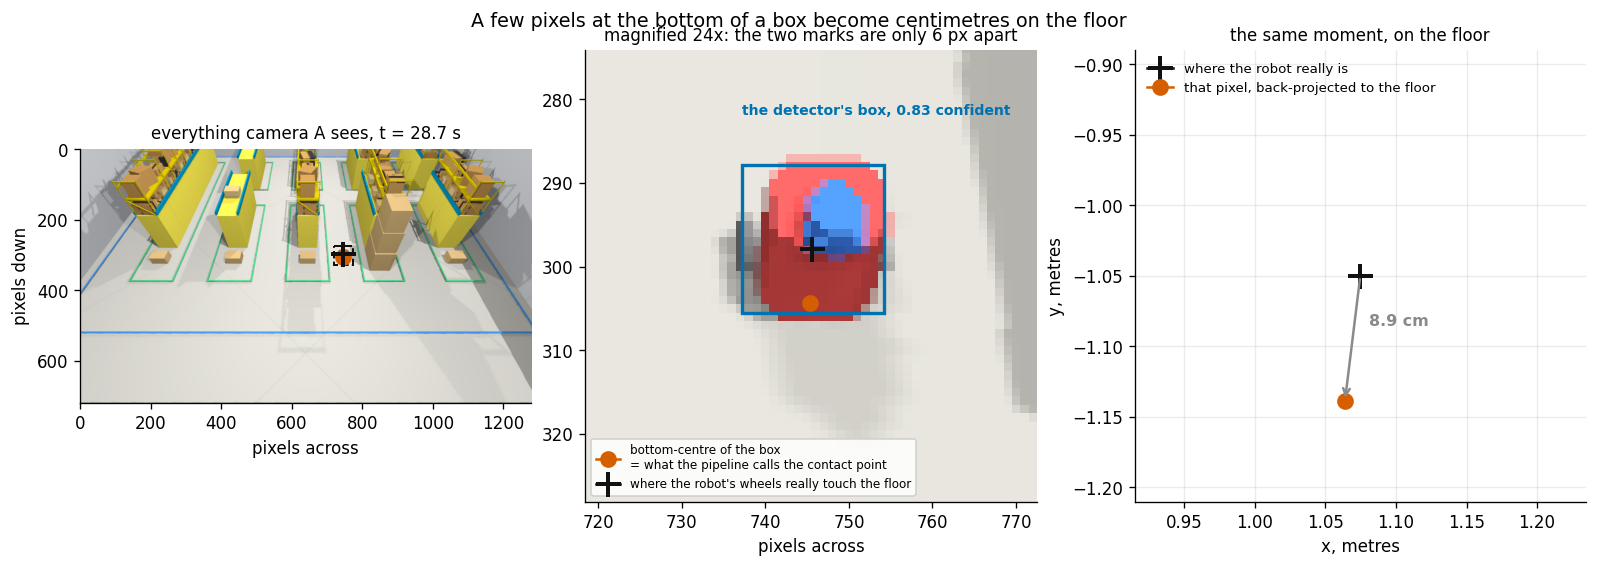

In [2]:
nv.the_camera_view(seq, capture, models, LEAD)

The two marks in the magnified panel are a handful of pixels apart, and that handful is
most of this notebook. Is it noise — the detector wobbling frame to frame — or is it a
**lean**, the same displacement every time? Only one of those can be modelled by a
covariance.

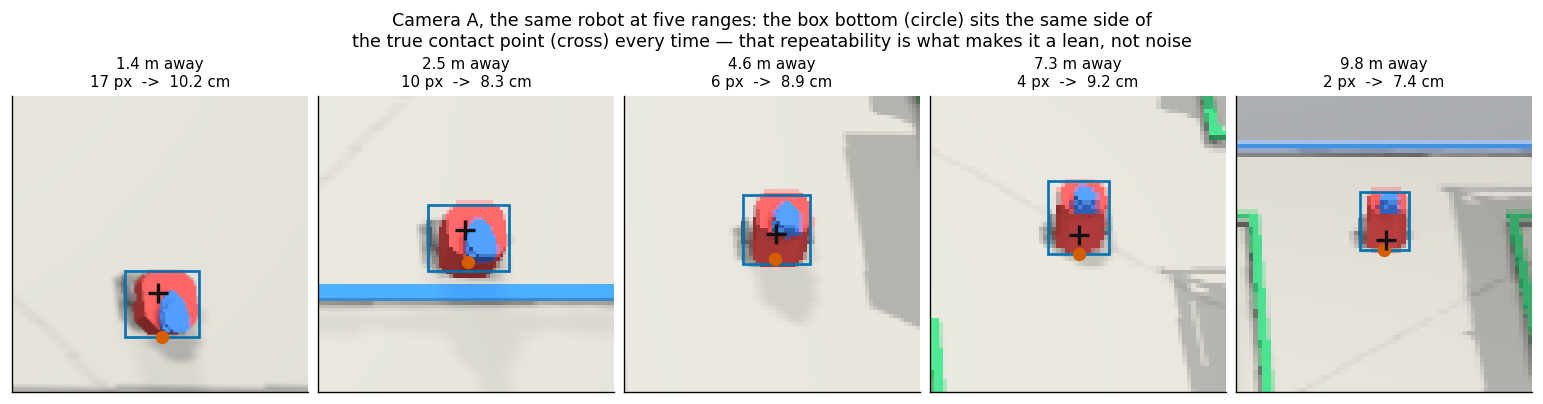

In [3]:
nv.the_camera_view_along_the_drive(seq, capture, models, LEAD)

It is a lean. The box bottom sits on the same side of the true contact point at every
range, near and far.

Read the two numbers in each title together, though, because they do not track each
other. Close to the camera the marks are far apart in pixels and the floor error is
moderate; far away they are only a couple of pixels apart and the floor error is about
the same. The pixel gap shrinks with range while the floor error does not, because a
pixel is worth more floor the further away it lands. **The error the filter sees is a
geometric quantity, not a detector quantity**, and the same is true of the noise around
it.

Now the other thing a single drive reveals, which four cameras would have hidden: what
one pixel of detector error is *worth*, in centimetres of floor, changes by a large
factor along this one drive. Near the camera the view is steep and a pixel is cheap;
far away the camera is looking along the floor and the same pixel is dear.

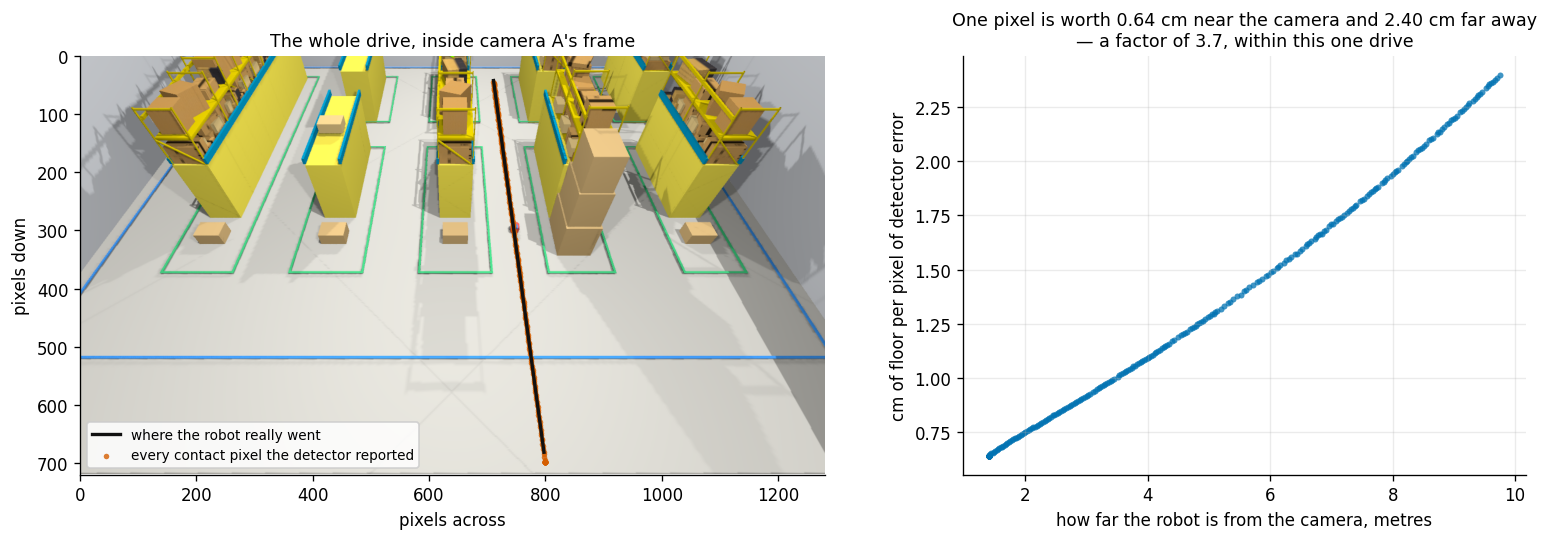

In [4]:
worth = nv.the_drive_in_the_image(seq, capture, models, LEAD)

## The model

Separate the symbols first. At time index $k$:

| symbol | meaning | known while driving? |
|---|---|---|
| $\mathbf{x}_k\in\mathbb{R}^2$ | where the robot really is | no — this is what we want |
| $\mathbf{u}_k\in\mathbb{R}^2$ | how far the wheels say it moved since $k-1$ | yes |
| $\mathbf{y}_k\in\mathbb{R}^2$ | the camera's reading, back-projected to the floor | yes, when there is one |
| $\mathbf{Q}_k$ | how wrong the wheels are | fixed here |
| $\mathbf{R}$ | how wrong the camera is | **this is what we are after** |

The model is two lines:

$$\mathbf{x}_k = \mathbf{x}_{k-1} + \mathbf{u}_k + \mathbf{q}_k,\quad \mathbf{q}_k \sim \mathcal{N}(\mathbf{0}, \mathbf{Q}_k)
\qquad\qquad
\mathbf{y}_k = \mathbf{x}_k + \mathbf{r}_k,\quad \mathbf{r}_k \sim \mathcal{N}(\mathbf{0}, \mathbf{R})$$

Read the second one against the pictures above, because the whole notebook turns on it.
It says the camera reports the true position **plus noise that averages to zero**.
There is no term in it for a camera that is consistently off in one direction. The
strip of crops shows a camera that is consistently off in one direction.

$\mathbf{R}$ is a **2×2 matrix**, not an error, not a vector, not an "amount wrong":

$$\mathbf{R} = \begin{bmatrix}\sigma_x^2 & \sigma_{xy}\\ \sigma_{xy} & \sigma_y^2\end{bmatrix}$$

The diagonal holds the variance along each axis; the off-diagonal says whether an error
across the aisle tends to come with one along it. Drawn, it is an **ellipse** — a size,
a shape and an orientation. That matters here rather than being pedantry, because this
camera's errors are nowhere near circular, and every other figure in this notebook
reduces $\mathbf{R}$ to the single number $\sigma=\sqrt{\operatorname{tr}\mathbf{R}/2}$
so that it fits on an axis. Before accepting that shorthand, look at what it discards.

The whole thing as one joint distribution — the recipe for generating a drive — with
$\mathcal{K}$ the steps where the camera spoke:

$$p(\mathbf{R}, \mathbf{x}_{0:T}, \mathbf{y}_\mathcal{K} \mid \mathbf{u}_{1:T}) =
  p(\mathbf{R})\, p(\mathbf{x}_0) \prod_{k=1}^{T} p(\mathbf{x}_k \mid \mathbf{x}_{k-1}, \mathbf{u}_k)
  \prod_{k \in \mathcal{K}} p(\mathbf{y}_k \mid \mathbf{x}_k, \mathbf{R})$$

Inference is Bayes' rule on that joint: fix $\mathbf{y}$ at what was recorded, ask
about everything else.

$$p(\mathbf{x}, \mathbf{R} \mid \mathbf{y}) = \frac{p(\mathbf{y} \mid \mathbf{x}, \mathbf{R})\, p(\mathbf{x})\, p(\mathbf{R})}{p(\mathbf{y})}
\qquad \text{posterior} = \frac{\text{likelihood} \times \text{prior}}{\text{evidence}}$$

In [5]:
nv.report_what_R_is(truth, None, LEAD)

  R is a 2x2 matrix, in cm^2. All three of these are R.

  what the errors actually are      [   0.59    5.71]   across  0.77 cm
                                    [   5.71   75.62]   along   8.70 cm, correlation +0.85
                                    centred on zero, so it has to be big enough to reach a cloud that is not

  their scatter alone               [   0.14   -0.08]   across  0.38 cm
                                    [  -0.08    1.24]   along   1.11 cm, correlation -0.20
                                    centred on the cloud, so it only describes the jitter

  and the part no covariance can hold: a mean error of (-0.67, -8.62) cm,
  the same direction on every one of 276 readings.


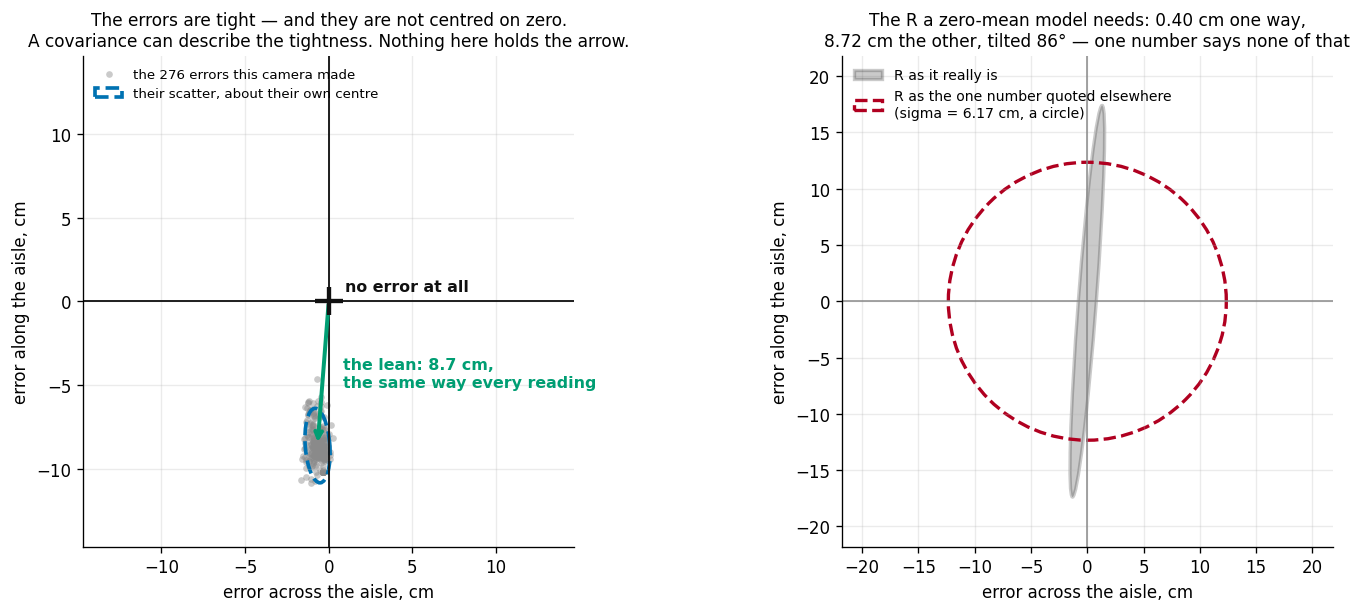

In [6]:
nv.what_R_is(seq, LEAD, truth)

Both ellipses are $\mathbf{R}$, and the argument of the notebook is already visible in
the left panel:

* the grey cloud is where this camera's errors actually fall, and it is **not centred on
  zero** — it sits a lean away from it;
* the dashed blue ellipse is the cloud's own shape about its own centre: small, and
  clearly longer one way than the other;
* the solid black ellipse is what $\mathbf{R}$ must be for a model that insists errors
  average to zero. It is not bigger because the camera is noisier; it is bigger because
  it is **centred in the wrong place and has to stretch to reach the data**.

The right panel is the same matrix drawn honestly and drawn as the single number this
notebook quotes everywhere else. Keep the difference in mind whenever a σ appears below.

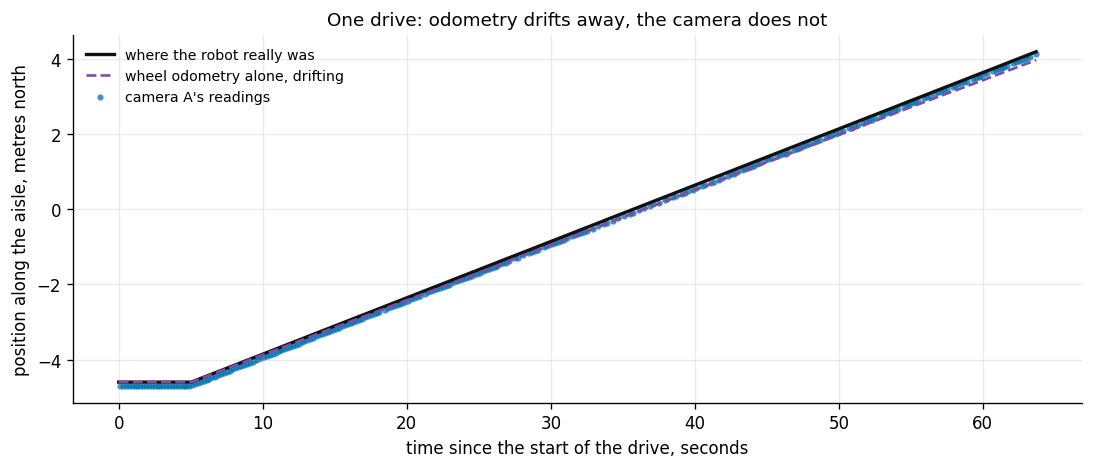

In [7]:
nv.the_run(seq, LEAD)

## If $\mathbf{R}$ were known

Then there is nothing to learn and the answer is closed form. `nm.kalman_filter` walks
forward: predict at every step, correct only where a reading exists.

$$\underbrace{\mathbf{m}_k^- = \mathbf{m}_{k-1} + \mathbf{u}_k, \qquad \mathbf{P}_k^- = \mathbf{P}_{k-1} + \mathbf{Q}_k}_{\text{predict: push the belief forward on the wheels}}$$

$$\underbrace{\mathbf{S}_k = \mathbf{P}_k^- + \mathbf{R}, \qquad
  \mathbf{K}_k = \mathbf{P}_k^-\mathbf{S}_k^{-1}, \qquad
  \mathbf{m}_k = \mathbf{m}_k^- + \mathbf{K}_k(\mathbf{y}_k - \mathbf{m}_k^-), \qquad
  \mathbf{P}_k = (\mathbf{I} - \mathbf{K}_k)\mathbf{P}_k^-}_{\text{correct: move part of the way towards the reading}}$$

$\mathbf{R}$ enters once, in $\mathbf{S}_k$, and it sets how far "part of the way" is.
Small $\mathbf{R}$ means the camera is trusted and the belief jumps most of the way to
the reading; large $\mathbf{R}$ means it barely moves.

Note $\mathbf{S}_k$ for later. It is also the **width of the filter's forecast for the
next reading**, which is what the prediction sections below are built on.

`nm.rts_smoother` afterwards makes one backward pass, so a later reading can revise an
earlier position. The filter is what a robot can run; the smoother is what an analyst
can run afterwards.

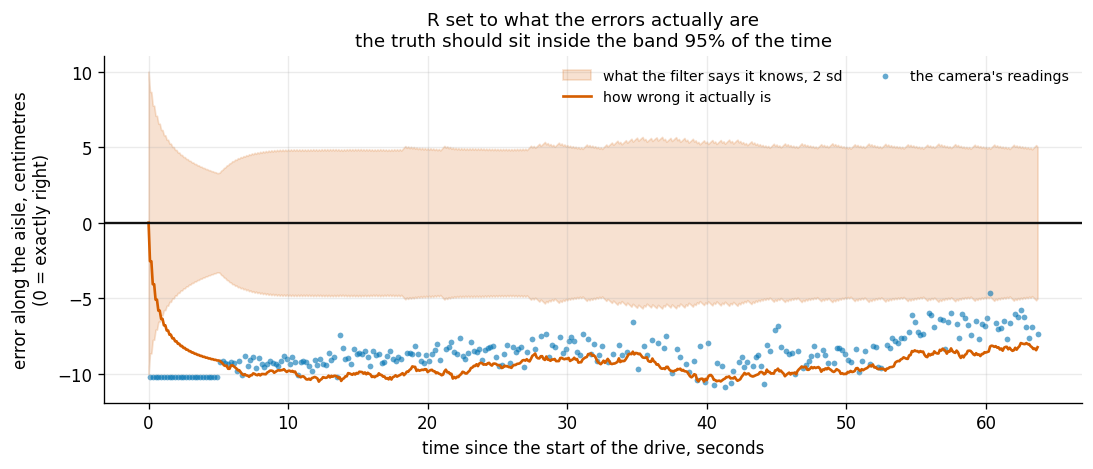

In [8]:
forward = nm.kalman_filter(seq, truth["R_total"])

nv.filter_with_R(seq, forward, LEAD, "R set to what the errors actually are")

## How to tell whether a belief is any good

The filter returns a mean **and** a covariance, so being close is only half of it — the
uncertainty it *claims* has to be right too. A filter that is 5 cm off and says so is
doing its job; a filter that is 5 cm off and claims 1 cm is dangerous, because the
planner believes it.

With $\mathbf{e}_k = \mathbf{x}_k^{\text{true}} - \mathbf{m}_k$,

$$\varepsilon_k = \mathbf{e}_k^{\!\top} \mathbf{P}_k^{-1} \mathbf{e}_k \;\sim\; \chi^2_2
  \quad\text{if the belief is honest}, \qquad \operatorname{median}(\chi^2_2) = 2\ln 2 = 1.386$$

This is the error measured in units of the filter's own stated uncertainty. Well above
1.386 = overconfident; well below = timid. Alongside it a proper score, which punishes
both kinds of wrongness at once (lower is better):

$$\text{NLPD} = -\log p(\mathbf{x}^{\text{true}} \mid \mathbf{y}) =
  \tfrac12\left(\varepsilon_k + \log\det 2\pi\mathbf{P}_k\right)$$

**Both need ground truth.** They are the analyst's instruments, not the robot's. Keep
that in mind — *Making a prediction* introduces a test that does not.

In [9]:
baseline = nm.honesty(forward, seq, "R = the true errors")

print(f"median normalised squared error {baseline['median_nees']:7.2f}   "
      f"(1.386 would be honest)")
print(f"  read plainly: the truth sits {nm.times_too_confident(baseline['median_nees']):.1f}x "
      f"further from the estimate than the filter says it should")
print(f"proper score                    {baseline['mean_nlpd']:7.2f}   (lower is better)")
print(f"RMSE                            {baseline['rmse_cm']:7.2f} cm")
print("\nNote what that means: even handed the RIGHT covariance, measured on this very")
print("drive with ground truth, the belief is not honest. Inflating R to cover a lean")
print("is not the same as modelling the lean, and this is as good as that trade gets.")

median normalised squared error   15.35   (1.386 would be honest)
  read plainly: the truth sits 3.3x further from the estimate than the filter says it should
proper score                       0.93   (lower is better)
RMSE                               9.43 cm

Note what that means: even handed the RIGHT covariance, measured on this very
drive with ground truth, the belief is not honest. Inflating R to cover a lean
is not the same as modelling the lean, and this is as good as that trade gets.


## $\mathbf{R}$ is unknown, so put a probability distribution on it

A covariance has to be symmetric and positive definite, so we cannot simply put a
Gaussian on its entries. The natural choice — the **conjugate** one — is the
inverse-Wishart $\mathcal{IW}(\Psi, \nu)$: $\Psi$ is a positive definite scale matrix
and $\nu$ says how strongly we believe it, behaving like a count of imaginary prior
observations.

Conjugate means the posterior stays in the same family, so updating is arithmetic
rather than integration. Given residuals $\mathbf{v}_k = \mathbf{y}_k - \mathbf{x}_k$,

$$p(\mathbf{R}) = \mathcal{IW}(\Psi, \nu) \;\longrightarrow\;
  p(\mathbf{R} \mid \mathbf{v}) = \mathcal{IW}\Big(\Psi + \textstyle\sum_k \mathbf{v}_k\mathbf{v}_k^{\!\top},\;\; \nu + |\mathcal{K}|\Big)$$

Every observation adds its own outer product to $\Psi$ and one to $\nu$. Nothing else
happens.

**Where that comes from.** With the residuals known, the Gaussian likelihood for
$\mathbf{R}$ is

$$p(\{\mathbf{v}_k\}\mid\mathbf{R})\propto
|\mathbf{R}|^{-n/2}\exp\!\left[-\tfrac12
\operatorname{tr}\!\left(\mathbf{R}^{-1}\sum_k
\mathbf{v}_k\mathbf{v}_k^\top\right)\right],$$

which has exactly the shape of an inverse-Wishart density in $\mathbf{R}$. Multiplying
by the prior adds the exponents of $|\mathbf{R}|$ and adds the matrices inside the
trace — hence the two additions above. No optimiser is involved in this step.

Two summaries of the posterior get used below: its mean is
$\Psi^{+}/(\nu^{+} - d - 1)$, while what the filter wants is the inverse of the expected
precision, $(\mathbb{E}[\mathbf{R}^{-1}])^{-1} = \Psi^{+}/\nu^{+}$.

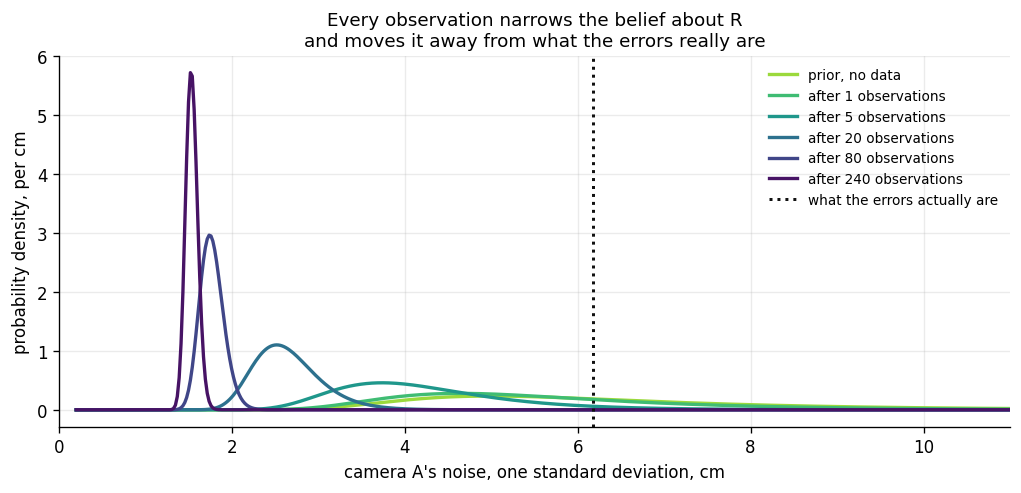

In [10]:
trace = nm.conjugate_trace(seq, LEAD, {1, 5, 20, 80, 240})

nv.conjugacy(trace, LEAD, truth["sigma_total_m"][LEAD], "what the errors actually are")

The same update, arriving one reading at a time.

In [11]:
nv.animate_conjugacy(seq, LEAD, truth["sigma_total_m"][LEAD],
                     "what the errors actually are")

## The catch: $\mathbf{x}$ and $\mathbf{R}$ need each other

That update needed the residuals $\mathbf{v}_k = \mathbf{y}_k - \mathbf{x}_k$ — the gap
between the reading and the true position. But the true position is exactly what we do
not have, and estimating it needed $\mathbf{R}$. The two unknowns are locked together.

The next figure makes that literal. For each trial value of $\sigma$,
`nm.sigma_fixed_point` runs one trajectory estimate, then one covariance update, and
reports what came back out. Where the curve crosses the diagonal, one full pass changes
nothing — that is where the loop of the next section has to end up, wherever it starts.
(A diagnostic sweep, not the algorithm.)

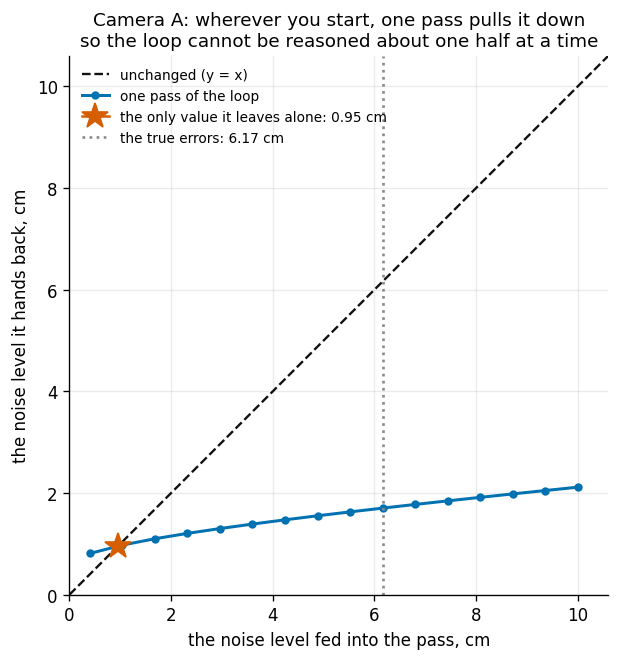

In [12]:
grid = np.linspace(0.004, 0.10, 16)

crossing = nv.fixed_point(grid, nm.sigma_fixed_point(seq, LEAD, grid), LEAD,
                          truth["sigma_total_m"][LEAD], "the true errors")

## The learning loop: variational inference

$p(\mathbf{x}, \mathbf{R} \mid \mathbf{y})$ has no closed form. So approximate it by
something that factorises, $q(\mathbf{x})\,q(\mathbf{R})$, and make the approximation as
close as it can be in KL divergence:

$$\mathrm{KL}(q \,\|\, p) = \int q \log \frac{q}{p} \;\ge\; 0, \qquad
  \log p(\mathbf{y}) = \underbrace{\mathbb{E}_q\!\left[\log \frac{p(\mathbf{x}, \mathbf{R}, \mathbf{y})}{q(\mathbf{x})q(\mathbf{R})}\right]}_{\mathcal{L}(q),\ \text{the ELBO}} + \mathrm{KL}\big(q \,\|\, p(\cdot \mid \mathbf{y})\big)$$

$\log p(\mathbf{y})$ is a fixed number, so pushing $\mathcal{L}$ up pulls $q$ towards
the true posterior. Maximising one factor at a time gives two steps, both closed form —
which is the entire appeal of this approach:

| | hold fixed | update | which is |
|---|---|---|---|
| $\mathbf{x}$ step | $q(\mathbf{R})$ | $q(\mathbf{x})$ | the Kalman filter + smoother at $\bar{\mathbf{R}} = (\mathbb{E}_q[\mathbf{R}^{-1}])^{-1}$ |
| $\mathbf{R}$ step | $q(\mathbf{x})$ | $q(\mathbf{R})$ | the conjugate update above, on the smoothed residuals |

One correction to that conjugate update, now that $\mathbf{x}$ is itself uncertain: the
smoother's own covariance is added in before the camera is charged, so the part of a
gap that the trajectory's vagueness already explains is not blamed on the camera.

$$\Psi^{+} = \Psi + \sum_{k \in \mathcal{K}}\Big[\underbrace{(\mathbf{y}_k - \mathbf{m}^s_k)(\mathbf{y}_k - \mathbf{m}^s_k)^{\!\top}}_{\text{how far the reading missed}} + \underbrace{\mathbf{P}^s_k}_{\text{how unsure we are of where it missed from}}\Big], \qquad \nu^{+} = \nu + |\mathcal{K}|$$

That second term is exact rather than a fudge, because under $q(\mathbf{x}_k)$

$$\mathbb{E}\!\left[(\mathbf{y}_k-\mathbf{x}_k)(\mathbf{y}_k-\mathbf{x}_k)^\top\right]
=(\mathbf{y}_k-\mathbf{m}^s_k)(\mathbf{y}_k-\mathbf{m}^s_k)^\top+\mathbf{P}^s_k.$$

It is also what separates this from simply fitting a covariance to residuals. One outer
pass of `nm.learn_R(seq, iterations=12)` is:

1. run `nm.kalman_filter` forward over every step at the current $\bar{\mathbf{R}}$;
2. run `nm.rts_smoother` backward over the same steps;
3. add up the two terms above over this camera's readings;
4. replace $q(\mathbf{R})$, and set $\bar{\mathbf{R}}=\Psi^+/\nu^+$ for the next pass.

The **same prior** is used on every pass. The loop does not count the same readings
twelve times; each pass rebuilds one approximation to the posterior from the prior plus
the currently estimated trajectory.

In [13]:
nv.report_one_conjugate_update(nm.one_conjugate_update(seq, LEAD))

camera A, 276 observations, starting from sigma = 5.00 cm

  cm^2
  residuals about the path      [   17.4    11.8]
                                [   11.8   102.0]
  + the smoother's own P        [  482.0     0.0]
                                [    0.0   482.0]
  + prior Psi                   [  150.0     0.0]
                                [    0.0   150.0]
  = Psi+                        [  649.5    11.8]
                                [   11.8   734.0]

  nu+ = 6 + 276 = 282
  Psi+ / nu+                    [    2.3     0.0]
                                [    0.0     2.6]

  sigma: 5.00 cm -> 1.57 cm     (89% of the scatter was the smoother's own P)


Read the middle of that table: part of the scatter this camera is charged with is not
the readings missing, it is the smoother's own uncertainty about where they missed
from. Now run all twelve passes.

In [14]:
R_learned, history, vb = nm.learn_R(seq)

# The reading that lands furthest outside the learned covariance's own forecast, skipping
# the start-up step. Both the forecast figure and the pass-by-pass figure draw this one.
hardest_step = int(max([r for r in nm.forecast(seq, R_learned)["rows"] if r["t"] > 1.0],
                       key=lambda r: r["nis"])["k"])

nv.report_learning(history, cameras=[LEAD])

    pass    how well it fits   learned noise, cm
       0              1643.7   A= 1.57
       1              1784.4   A= 1.08
       2              1815.1   A= 0.99
       3              1821.9   A= 0.96
      12              1823.8   A= 0.96
  (passes 4 to 11 omitted; nothing moves after 3)


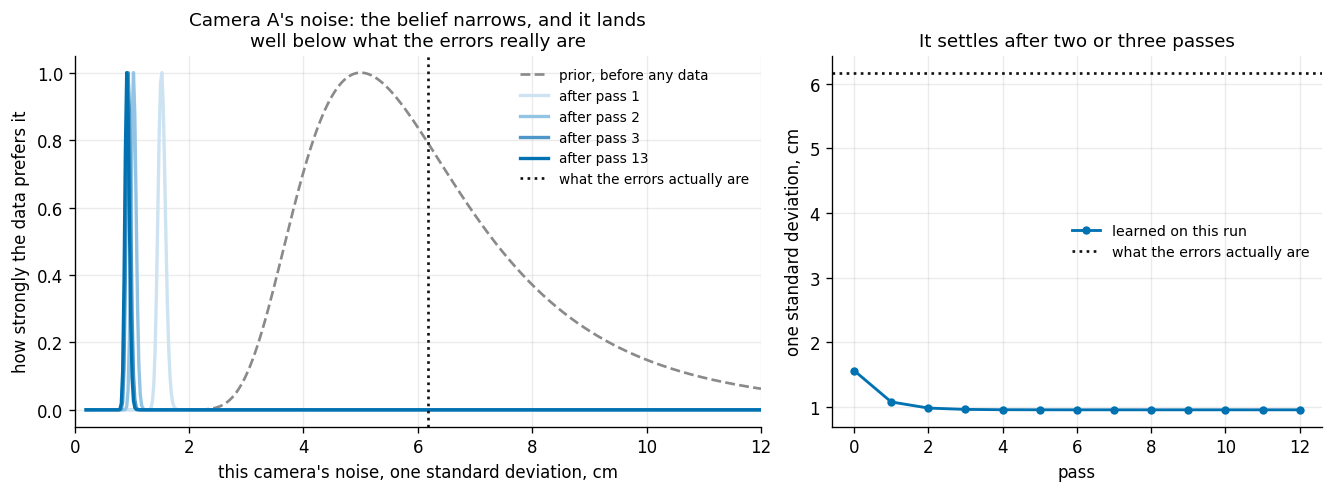

In [15]:
nv.single_camera_posterior(history, LEAD, truth["sigma_total_m"][LEAD],
                           "what the errors actually are")

In [16]:
nv.report_what_R_is(truth, R_learned, LEAD)

  R is a 2x2 matrix, in cm^2. All three of these are R.

  what the errors actually are      [   0.59    5.71]   across  0.77 cm
                                    [   5.71   75.62]   along   8.70 cm, correlation +0.85
                                    centred on zero, so it has to be big enough to reach a cloud that is not

  their scatter alone               [   0.14   -0.08]   across  0.38 cm
                                    [  -0.08    1.24]   along   1.11 cm, correlation -0.20
                                    centred on the cloud, so it only describes the jitter

  learned from this drive           [   0.83    0.03]   across  0.91 cm
                                    [   0.03    1.00]   along   1.00 cm, correlation +0.03
                                    found with no ground truth at all

  and the part no covariance can hold: a mean error of (-0.67, -8.62) cm,
  the same direction on every one of 276 readings.


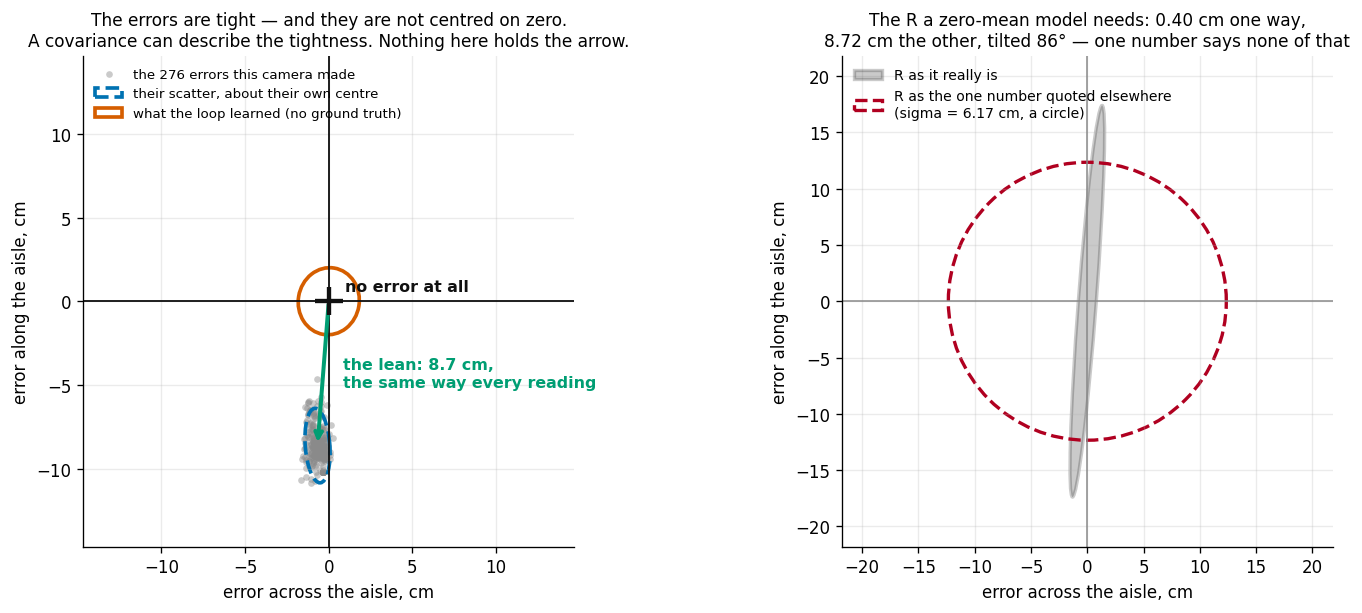

In [17]:
nv.what_R_is(seq, LEAD, truth, R_learned)

### What actually happens as the loop turns

Three things change on each pass and it is worth watching all three: what the loop
believes $\mathbf{R}$ is, what that belief forecasts for the readings, and whether the
quantity being maximised has gone up. The middle row draws **every** reading, not a
chosen one — a single observation cannot tell you whether the forecast is improving, and
picking a dramatic one tells you the opposite of the truth.

That last one needs care. The **ELBO** is what coordinate ascent provably climbs, and it
is not the plug-in fit plotted earlier — that is a different quantity evaluated at a
point estimate, and nothing guarantees it rises. `nm.elbo` computes the bound exactly by
evaluating it straight after an $\mathbf{x}$ step, where $q(\mathbf{x})$ is exactly
$p(\mathbf{x}\mid\mathbf{y},\bar{\mathbf{R}})$ and so

$$\mathbb{E}_{q(\mathbf{x})}[\log p(\mathbf{y}\mid\mathbf{x},\bar{\mathbf{R}})]
  - \mathrm{KL}(q(\mathbf{x})\,\|\,p(\mathbf{x})) = \log p(\mathbf{y}\mid\bar{\mathbf{R}}),$$

which the filter already accumulates. Two corrections remain — the likelihood wants
$\mathbb{E}[\log|\mathbf{R}|]$ rather than $\log|\bar{\mathbf{R}}|$, and the prior
contributes $-\mathrm{KL}(q(\mathbf{R})\,\|\,p(\mathbf{R}))$.

**Against the course notebook.** PP4 asks RxInfer for the same thing —
`infer(..., free_energy = true)` — and gets back the **Bethe free energy**. Two
differences worth stating so the numbers are never compared naively:

* **sign.** RxInfer reports a free energy, which is *minimised* and equals
  $-\mathcal{L}(q)$. The curve below is the ELBO, which is *maximised*. Same object,
  opposite direction.
* **which noise.** PP4 puts the inverse-Wishart prior on $\mathbf{Q}$, the *process*
  noise, because its sensor variance is known from calibration. Here it is the mirror
  image: the odometry is the well-characterised part and the *camera* is what we do not
  trust, so the prior goes on $\mathbf{R}$.

The Bethe free energy is exact on a tree-structured factor graph, and a chain is a tree,
so for this model class the two are the same quantity and not merely analogous. What is
computed below is that quantity in closed form — no message-passing engine, because the
model is conditionally conjugate and the x half collapses onto the filter's own evidence.

Run it out to a hundred passes and look at the prior, one pass, and ten.

In [18]:
R_100, history_100, _ = nm.learn_R(seq, iterations=100)

nv.report_passes_of_the_loop(history_100, LEAD, truth, seq=seq)

    pass  R across, cm  R along, cm   the ELBO plug-in fit
       0         5.000        5.000   1020.930     1643.72   <- the prior, before any learning
       1         1.518        1.613   1596.294     1784.41
      10         0.913        1.002   1678.914     1823.84
   truth         0.769        8.696                         <- what the errors actually are

  across the aisle the loop is right: 0.91 cm against a true 0.77 cm.
  along the aisle it is not: 1.00 cm against a true 8.70 cm, 9x too small --
  and along the aisle is exactly the direction the lean points.

  and what that does to the forecast, over ALL of this camera's readings:

    pass    it forecasts     readings land    as a fraction
             +- this, cm  this far off, cm  of the forecast
       0            5.37              0.98             0.15
       1            1.96              0.67             0.26
      10            1.37              0.65             0.40

  THE MISS GOES DOWN, not up: the readings land

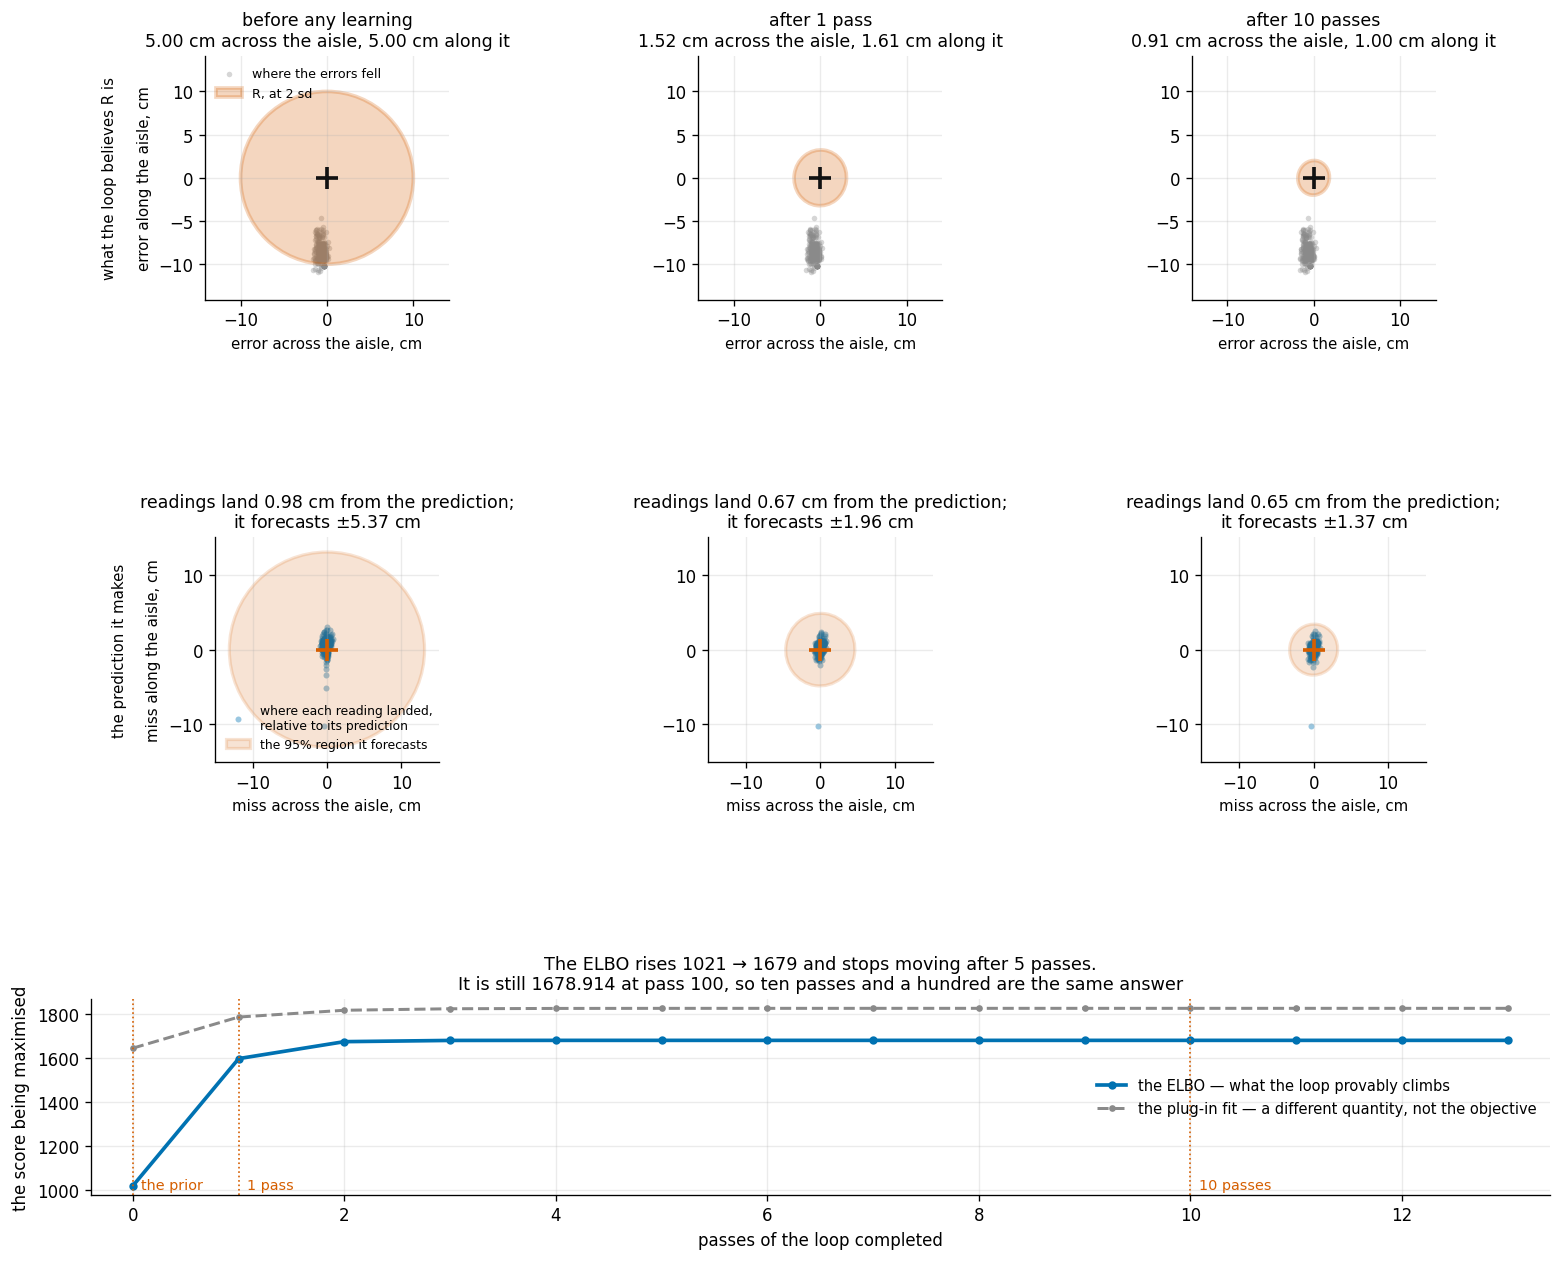

In [19]:
nv.passes_of_the_loop(seq, LEAD, history_100, truth, hardest_step)

**It is over after about five passes.** Ten and a hundred are the same answer to three
decimals, so nothing in this notebook would change if the loop ran all night. The first
column is the prior, before any learning: a 5 cm circle wide enough to swallow the whole
error cloud. One pass takes it to 1.5 cm, and by ten it has settled at 0.96 cm.

### The prediction error does not grow — read the middle row carefully

It is easy to look at that row and conclude the opposite, so the numbers are worth
stating flatly. Over all 276 readings, as the loop iterates:

| | before learning | 1 pass | 10 passes |
|---|---|---|---|
| the forecast claims | ±5.37 cm | ±1.96 cm | ±1.37 cm |
| the readings actually land | 0.98 cm off | 0.67 cm off | 0.65 cm off |
| so, as a fraction of the forecast | 0.15 | 0.26 | 0.40 |

**The miss goes down.** The readings land *closer* to the prediction on every pass, and
the forecast score improves accordingly — the loop really is getting better at
predicting the camera, which is the finding this whole notebook rests on.

What goes **up** is the third row: the miss measured against a forecast that is
narrowing faster than the miss is. The claimed width falls by 3.9× while the actual miss
falls by only 1.5×, so the gap between them opens even as both shrink. Those two
statements are not in conflict, and keeping them apart is the difference between "the
fit is broken" and "the fit is fine and is answering the wrong question".

The ELBO rises on every single step of all hundred, which is the sharpest check on the
implementation available: coordinate ascent that ever went downhill would be a bug, and
it never does. Note also that the plug-in fit is a *different curve* — higher, and not
the thing being maximised. Quoting it as "the objective" would be wrong.

And the per-axis numbers in the table are the clearest statement of what has gone wrong
anywhere in this notebook. **Across** the aisle the loop says 0.91 cm and the truth is
0.77 cm — near enough right. **Along** the aisle it says 1.00 cm and the truth is
8.70 cm, nine times larger. Along the aisle is exactly the direction the lean points.
The loop is not uniformly overconfident; it is correct in the direction where the model
holds and wrong in the direction where it does not.

The orange ellipse is the whole notebook in one picture. It is small — the loop has
correctly measured how tightly the readings cluster — and it is drawn **around zero**,
because that is where the model insists the errors are centred. Not one of the 276
errors landed anywhere near there.

The loop has not failed at its job. It has answered the only question its model can
ask, and answered it well; the question simply was not the one that mattered.

The loop converges quickly and stably on a camera far more precise than its errors
really are. That is a large disagreement, and it deserves the obvious first suspicion:
that the code is wrong.

Before testing that, notice **where** it landed. Compare the learned number against the
two references printed at the top of this notebook: it is nowhere near the covariance
that describes the errors, and it is very close to the covariance that describes their
**scatter alone**. The loop has not failed to estimate something. It has estimated the
scatter, correctly, and there is no term anywhere in its model for the rest.

## Is the implementation wrong?

Two things could be. Both are testable, so neither needs to be argued about.

**Suspicion 1 — the loop throws away its own counter-evidence.** The filter rejects a
reading whose innovation is too large for the current $\mathbf{R}$ (the standard 95%
$\chi^2$ gate). As $\mathbf{R}$ shrinks that test gets stricter, so the loop could be
discarding exactly the residuals that would keep it honest, and shrinking further as a
result. Run it again with the gate off.

In [20]:
nv.report_gate_ablation(nm.learning_gate_ablation(seq, LEAD))

  gate on (as shipped)  kept 276 of 276 readings   ->  0.96 cm
                        first six passes, cm:  1.57  1.08  0.99  0.96  0.96  0.96
  gate off              kept 276 of 276 readings   ->  0.96 cm
                        first six passes, cm:  1.57  1.08  0.99  0.96  0.96  0.96

  Turning the gate off moves the answer by 0.00 cm. That is not where the shrinkage comes from.


**Suspicion 2 — the update equations themselves.** The way to settle this is to hand the
estimator data that its model describes *perfectly* and see whether it returns the right
answer. Below, the real drive is kept exactly as recorded — same timing, same gaps, same
odometry — but every camera reading is replaced by one drawn from the assumed model,
$\mathbf{y} = \mathbf{x}^{\text{true}} + \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$,
with $\sigma$ chosen by us. Since we know what generated it, we know what the answer
should be.

**This is a test of the code, not an experiment.** Nothing in this cell is a statement
about the warehouse, and no number from it is quoted anywhere else.

Give it readings its own model describes exactly:

    the noise put in  plus a lean of     what it learned       recovered
             2.00 cm         0.00 cm           1.91 cm         95% +- 2%
             3.00 cm         0.00 cm           2.68 cm         89% +- 3%
             5.00 cm         0.00 cm           4.26 cm         85% +- 4%
             9.00 cm         0.00 cm           7.25 cm         81% +- 5%
            15.00 cm         0.00 cm          11.25 cm         75% +- 9%
             3.00 cm         9.00 cm           2.73 cm         91% +- 2%

  averaged over 6 independent draws of 276 readings each


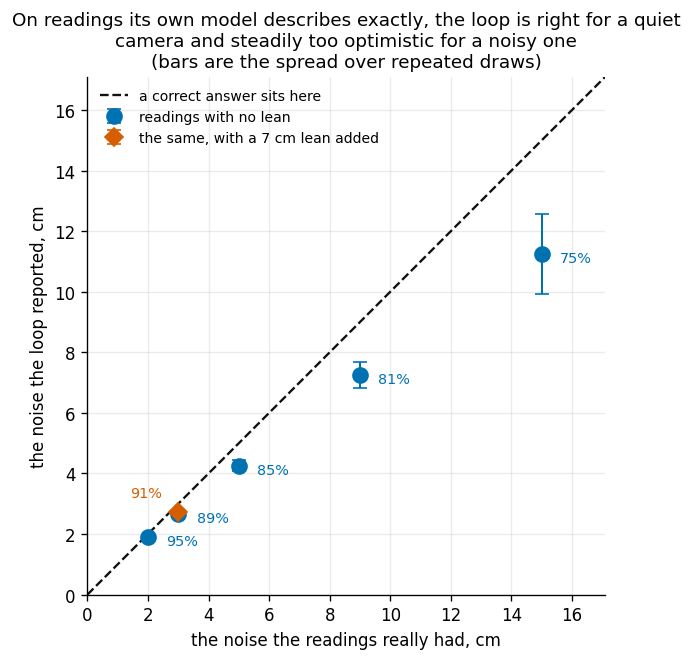

In [21]:
recovered = nm.recovery_check(
    seq, LEAD,
    [(0.02, 0.0), (0.03, 0.0), (0.05, 0.0), (0.09, 0.0), (0.15, 0.0), (0.03, 0.09)])

nv.report_recovery(recovered, heading="Give it readings its own model describes exactly:")
nv.recovery(recovered)

The arithmetic is sound, and there is a second thing in that table. For a genuinely
quiet camera the loop recovers the truth almost exactly; as the true noise grows it
reports steadily **less** than there really is. That is not a bug: a large $\mathbf{R}$
and a permissive $\mathbf{Q}$ describe overlapping possibilities, and a smoother free to
move the path can always explain part of a large residual by moving it there. The last
section measures how far that goes.

And the last row is worth pausing on. A lean the size of the one in the pictures above
passes through the estimator without leaving a trace — the trajectory absorbs it and
the loop never sees it. Hold on to that.

The rest of the notebook takes the loop at its word and asks what its answer is worth.

## Why does it fit the readings better?

It does fit better, and the reason is not the one you would guess.

Score a candidate $\mathbf{R}$ by how probable it made each reading **before that
reading arrived**:

$$\log p(\mathbf{y}_k \mid \mathbf{y}_{1:k-1}) =
  \underbrace{-\tfrac12 \mathbf{v}_k^{\!\top}\mathbf{S}_k^{-1}\mathbf{v}_k}_{\text{penalty: the reading missed}}
  \;\underbrace{-\tfrac12 \log\det 2\pi\mathbf{S}_k}_{\text{credit: the forecast was narrow}},
  \qquad \mathbf{S}_k = \mathbf{P}_k^- + \mathbf{R}$$

Summed over the drive this is the log marginal likelihood — the model evidence. It has
**two ways to go up**: the readings can land closer to where they were predicted, or the
prediction can simply be declared narrower. Those are very different achievements and
the total does not distinguish them. So take them apart.

(Every arm is scored ungated, over the same readings. A gate admits a different subset
for each $\mathbf{R}$, and totals over different data are not comparable.)

In [22]:
ARMS = [("what the errors actually are", truth["R_total"], nv.C_TRUTH),
        ("their scatter alone", truth["R_spread"], nv.C_SMOOTH),
        ("learned from this drive", R_learned, nv.C_FILTER)]
forecasts = [dict(nm.forecast(seq, R), label=label, colour=colour)
             for label, R, colour in ARMS]
summaries = [nm.forecast_summary(f, f["label"]) for f in forecasts]

nv.report_forecast_scores(summaries, heading=f"Forecasting camera "
                                             f"{LEAD.replace('camera_', '')}'s next reading:")

Forecasting camera A's next reading:

  candidate R                     forecast  reading  inside  typical   score
                                 width, cm   missed the 95% surprise     per
                                             by, cm ellipse          reading
  what the errors actually are        6.46     1.38    100%     0.07    5.26
  their scatter alone                 1.24     0.66    100%     0.18    6.97
  learned from this drive             1.37     0.65    100%     0.16    6.61

  'inside the 95% ellipse' should be 95%; 'typical surprise' should be 1.39,
  so every row here is UNDER-confident about the reading it is about to get.
  'score' is the average log-probability the filter gave the reading that
  actually arrived, before it arrived. Higher is a better forecast.


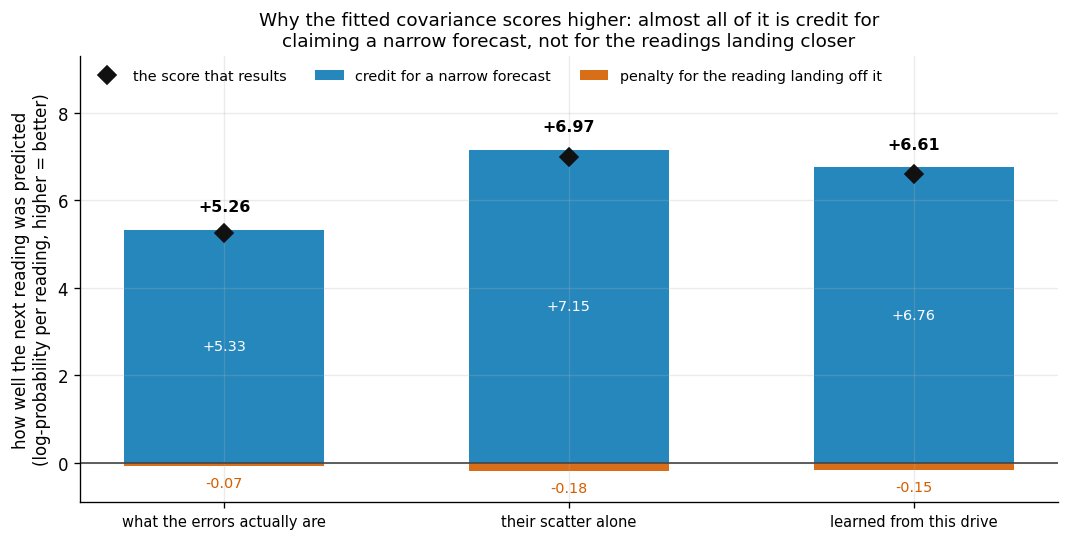

In [23]:
nv.why_it_fits_better(summaries)

There it is. Going from the true covariance to the learned one, the credit for a narrow
forecast improves far more than the penalty for missing worsens. Almost all of the
improved fit is the model claiming to be surer, not the model being more right — and it
is *entitled* to claim that, because the readings really do land close to the
prediction. Why they do comes later, in *How can both be true at once?*

Read the middle row too. The **true scatter** scores almost as well as the learned
covariance, and both beat the covariance that is actually correct for this camera. The
forecast is not rewarding accuracy about the camera; it is rewarding narrowness, and the
narrowest defensible answer is the one that ignores the lean.

## Making a prediction

Everything so far was fit. Now the actual forecast.

At any step the filter already implies a full distribution for the next reading, formed
from everything up to but **not including** it:

$$\mathbf{y}_k \mid \mathbf{y}_{1:k-1} \;\sim\; \mathcal{N}\big(\mathbf{m}_k^-,\; \mathbf{S}_k\big),
\qquad \mathbf{S}_k = \underbrace{\mathbf{P}_k^-}_{\text{unsure where the robot is}} + \underbrace{\mathbf{R}}_{\text{unsure what the camera does}}$$

This is a real prediction and it can be checked against what arrives. Crucially it needs
**no ground truth at all** — so unlike every score so far, it is a test the robot could
run on itself while driving.

This camera sees the robot almost continuously, so there is no long dead-reckoning
stretch to make an example of. The instructive moment is a different one: the reading
that landed **furthest outside the learned covariance's own forecast**, measured in
units of that forecast's width. It is the strongest case the drive offers against the
fitted covariance being too tight.

the camera never went quiet for longer than 0.4 s, and typically for 0.2 s
the hardest reading for the learned covariance arrives at t = 13.7 s


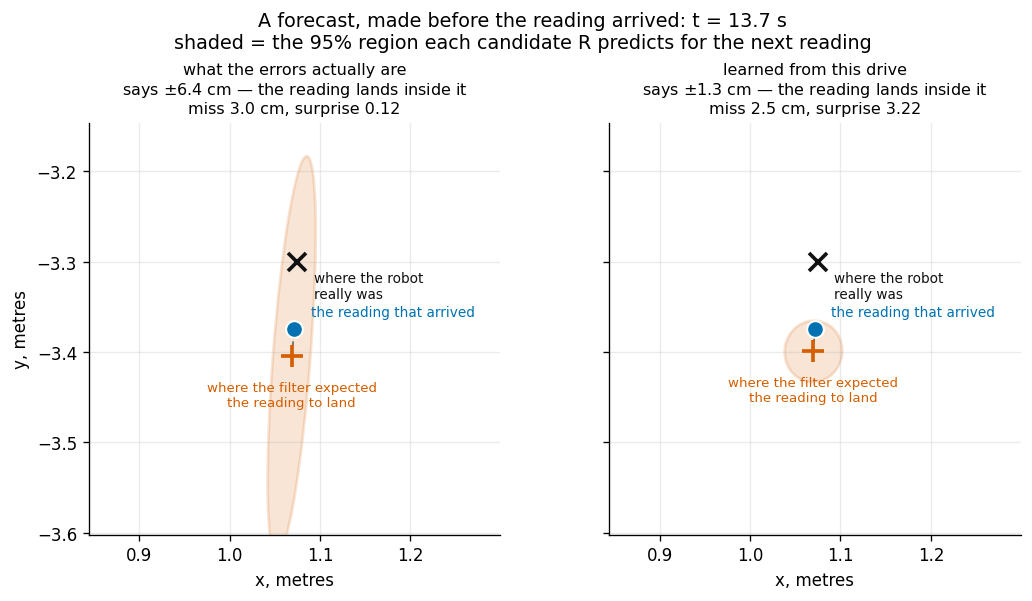

In [24]:
spoke_at = np.flatnonzero(seq.observed)
silence = np.diff(np.concatenate([[-1], spoke_at]))
print(f"the camera never went quiet for longer than {silence.max() / 10:.1f} s, "
      f"and typically for {np.median(silence) / 10:.1f} s")

print(f"the hardest reading for the learned covariance arrives at "
      f"t = {seq.stamps[hardest_step] - seq.stamps[0]:.1f} s")

nv.one_forecast(seq, [forecasts[0], forecasts[2]], hardest_step, LEAD)

Even at its hardest, the reading lands inside both forecasts. Note what that means:
the online check never complains. Now every forecast in the drive, scored the same way —
and read the left panel against the honest line, not just against the other arm.

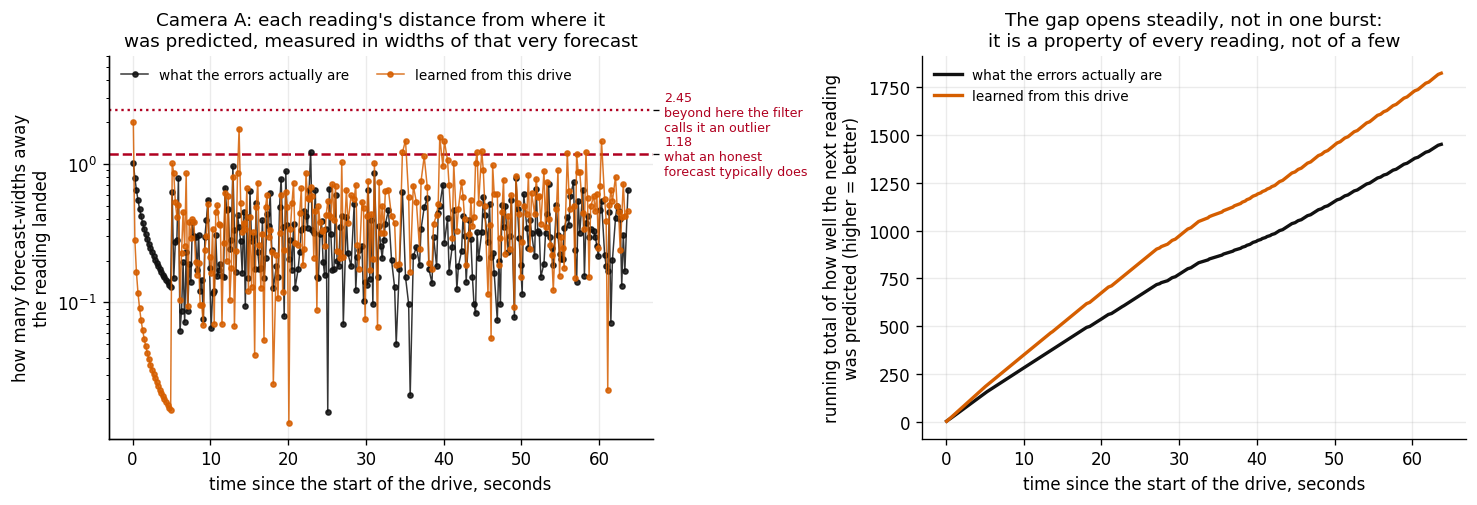

In [25]:
nv.forecasts_over_the_run([forecasts[0], forecasts[2]], LEAD)

## Does it predict better on data it has never seen?

So far the learned covariance has only been asked about the drive it was fitted on,
where it is entitled to look good. Two harder tests:

1. **Hold back time.** Fit $\mathbf{R}$ on the first half of this drive; score it on the
   second half.
2. **Hold back the drive.** Score it on the three other recorded drives — different
   routes and different viewing geometry, each judged against its own true errors.

And score two different things, because they are not the same question:

| question | measured by | needs ground truth? |
|---|---|---|
| how well does it predict **the camera's next reading**? | forecast score, and how often the reading lands in the predicted 95% region | **no** |
| how well does it know **where the robot is**? | error in units of the filter's own stated uncertainty | yes |

In [26]:
half = seq.n_steps // 2
R_first_half, _, _ = nm.learn_R(nm.observations_between(seq, 0, half))

print(f"learned on the whole drive       "
      f"{100 * float(np.sqrt(np.trace(R_learned[LEAD]) / 2)):.2f} cm")
print(f"learned on the first half only   "
      f"{100 * float(np.sqrt(np.trace(R_first_half[LEAD]) / 2)):.2f} cm")
print("\nAlmost the same answer from half the data, so what follows is not sampling noise.")

learned on the whole drive       0.96 cm
learned on the first half only   1.16 cm

Almost the same answer from half the data, so what follows is not sampling noise.


In [27]:
HOLD_OUT_ARMS = [("this drive's true errors", truth["R_total"]),
                 ("their scatter alone", truth["R_spread"]),
                 ("learned here, first half", R_first_half)]
DRIVES = [("this drive, first half", seq, (0, half)),
          ("this drive, later half", seq, (half, seq.n_steps))]
SHORT = {"aws_apron_west_to_east": "apron, west to east",
         "aws_aisle_west_north": "the other aisle",
         "aws_mid_cross_east": "the far cross-aisle"}
DRIVES += [(SHORT[tag], nm.other_run(tag, LEAD, models=models), None)
           for tag in OTHER_DRIVES]

held_out = []
for drive_name, drive_seq, steps in DRIVES:
    for label, R in HOLD_OUT_ARMS:
        forecast_here = nm.forecast_summary(nm.forecast(drive_seq, R, only=steps), label)
        belief_here = nm.honesty(nm.kalman_filter(drive_seq, R), drive_seq, label, steps=steps)
        held_out.append({"drive": drive_name, "label": label, "n": forecast_here["n"],
                         "log_p_mean": forecast_here["log_p_mean"],
                         "inside_95": forecast_here["inside_95"],
                         "median_nees": belief_here["median_nees"],
                         "rmse_cm": belief_here["rmse_cm"]})

nv.report_held_out(held_out,
                   heading="Only the first block was fitted on its own data:")

Only the first block was fitted on its own data:

  drive                   candidate R                 predicts the  how much too     RMSE
                                                      next reading    sure it is         
  this drive, first half  this drive's true errors            5.33          3.5x    9.5 cm
                          their scatter alone                 7.12          9.7x    9.1 cm
                          learned here, first half            6.46          9.1x    9.1 cm

  this drive, later half  this drive's true errors            5.17          3.2x    9.4 cm
                          their scatter alone                 6.80          8.3x    8.5 cm
                          learned here, first half            6.27          7.8x    8.5 cm

  apron, west to east     this drive's true errors            5.27          8.6x   10.2 cm
                          their scatter alone                 7.09         14.6x   10.2 cm
                          learned here, 

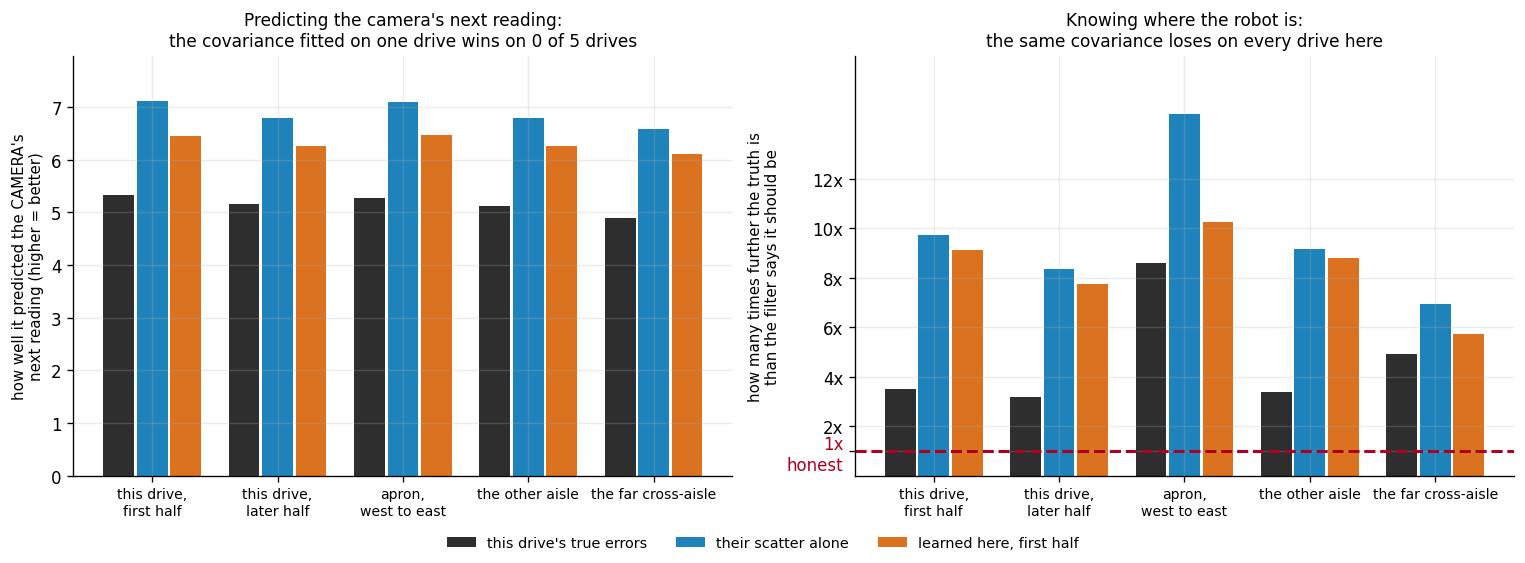

In [28]:
nv.camera_versus_robot(held_out)

### The answer, in two parts

**Yes, it predicts the camera better — everywhere, and the advantage does not fade.**
It
wins the forecast on the half it was fitted on, on the half it was not, and on all three
other routes, by a margin that barely changes between them. This is not overfitting; the
fitted covariance really is a better description of how far the next reading lands from
where the filter expected it.

**And it knows where the robot is worse — everywhere, by a factor of five to seven.** No
row of that column goes the other way either.

The two criteria are therefore not merely different, they are **cleanly and consistently
opposed**: on this evidence, choosing $\mathbf{R}$ by how well it predicts the next
reading picks the least honest belief available, on every drive tested. And the criterion
that gets it wrong is the only one a robot can compute for itself.

One more thing worth reading off the scoreboard: every arm's typical surprise is far
*below* 1.386, so as a forecaster of the camera even the learned covariance is
under-confident — while as a belief about the robot it is a hundred times overconfident.
The same matrix, at the same instant, is too timid about one thing and wildly too sure
about the other. They are simply not the same quantity.

## How can both be true at once?

Because of what the filter is able to be surprised by.

The forecast is checked against $\mathbf{v}_k = \mathbf{y}_k - \mathbf{m}_k^-$: the
reading minus the prediction. Suppose the camera leans — reports a position
consistently displaced by some $\mathbf{b}$, the same way every frame, which is exactly
what the crops at the top of this notebook show. Then after a few readings the filter's
own estimate has been dragged onto the leaning readings, so $\mathbf{m}_k^-$ carries
$\mathbf{b}$ too, and it **cancels**:

$$\mathbf{v}_k = (\mathbf{x}_k + \mathbf{b} + \boldsymbol\eta_k) - (\mathbf{x}_k + \mathbf{b}) = \boldsymbol\eta_k$$

The lean is in the camera and it is in the belief, and it is absent from the one
quantity that both the fit and the forecast are scored on. Three errors at the same
instants:

In [29]:
views = [(label, nm.what_the_innovation_sees(seq, R)) for label, R, _ in ARMS]

nv.report_bias_invisible(views)

  candidate R                          the camera is       the belief is       the filter is
                                        wrong by, cm        wrong by, cm    surprised by, cm
  what the errors actually are        (-0.67, -8.62)      (-0.72, -9.33)      (+0.03, +0.75)
  their scatter alone                 (-0.67, -8.62)      (-0.66, -8.72)      (-0.03, +0.15)
  learned from this drive             (-0.67, -8.62)      (-0.66, -8.71)      (-0.03, +0.14)

  The first two columns need ground truth and are not available on a robot.
  The third is what both the fit and the forecast are actually scored on.


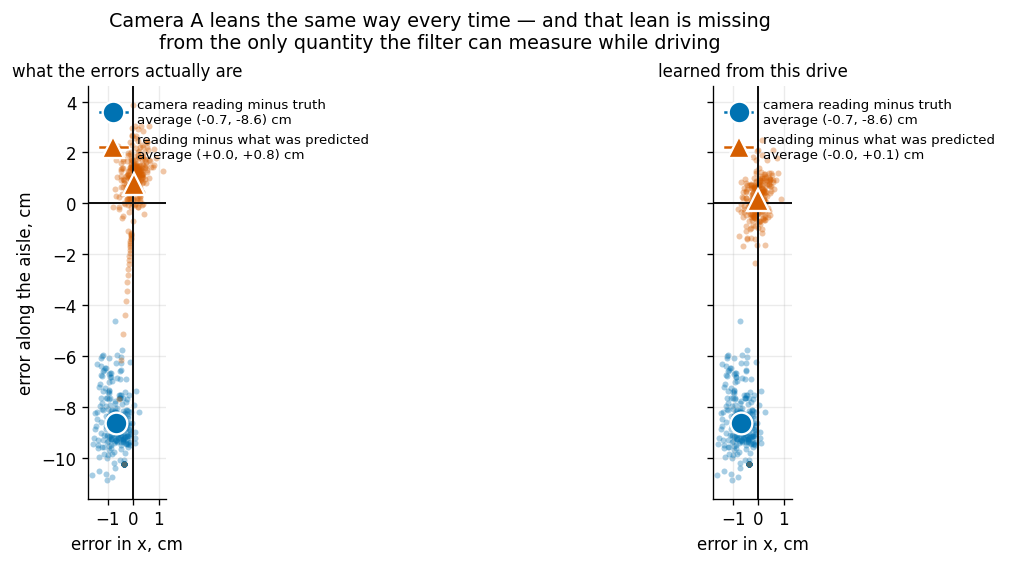

In [30]:
nv.bias_is_invisible([views[0], views[2]], LEAD)

That is the whole result. Fitting $\mathbf{R}$ optimises agreement between the readings
and a trajectory that has itself been fitted to those readings, and a self-consistent
lean is invisible to that comparison. So the procedure is free to keep shrinking
$\mathbf{R}$, gets rewarded for it, and the reward is real — it genuinely does predict
the readings better. It is simply not measuring the thing the robot needs.

And the mechanism compounds. Where there is no reading the smoother is free to move the
path onto the leaning ones; the $\mathbf{R}$ step then measures scatter about that moved
path, finds it small, and returns a smaller covariance; the next pass trusts the camera
more and moves further.

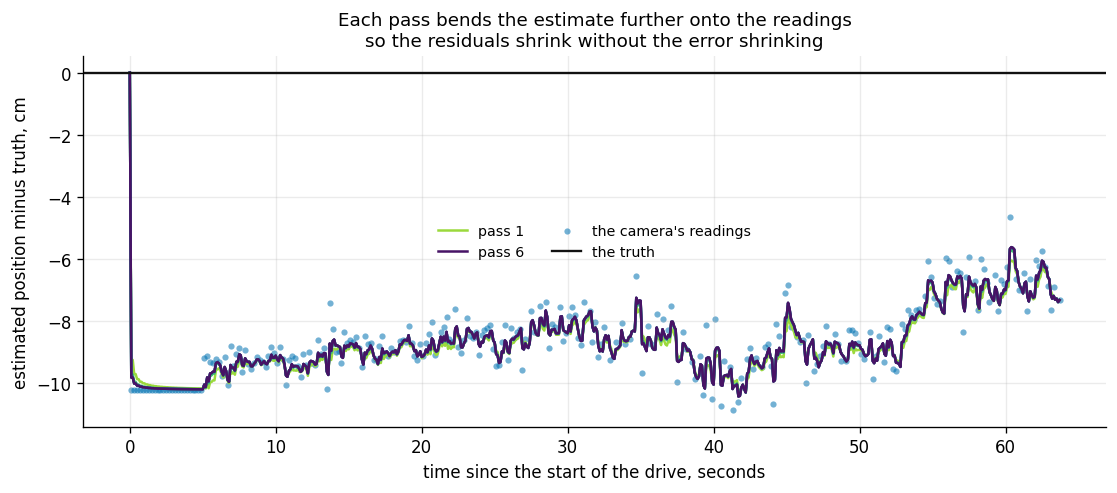

In [31]:
nv.path_bending(seq, nm.path_per_pass(seq, history)[:6], LEAD)

## What this drive actually determines

One last measurement, which reframes the whole exercise.

$\mathbf{R}$ and $\mathbf{Q}$ both describe how far the readings and the dead-reckoned
path are allowed to drift apart. A single drive constrains their **combination**, not
either one alone. So repeat the learning under different assumptions about the wheels
and watch what "this camera's noise" turns out to be.

     assumed wheel noise    learned camera noise   belief honesty       RMSE
                   0.005                 0.93 cm          1006.97     10.0 cm
                   0.010                 0.89 cm           492.16      9.1 cm
                   0.020                 0.91 cm           241.53      8.9 cm
                   0.040                 0.96 cm           115.50      8.8 cm
                   0.080                 1.07 cm            50.36      8.7 cm
                   0.160                 1.28 cm            18.28      8.7 cm


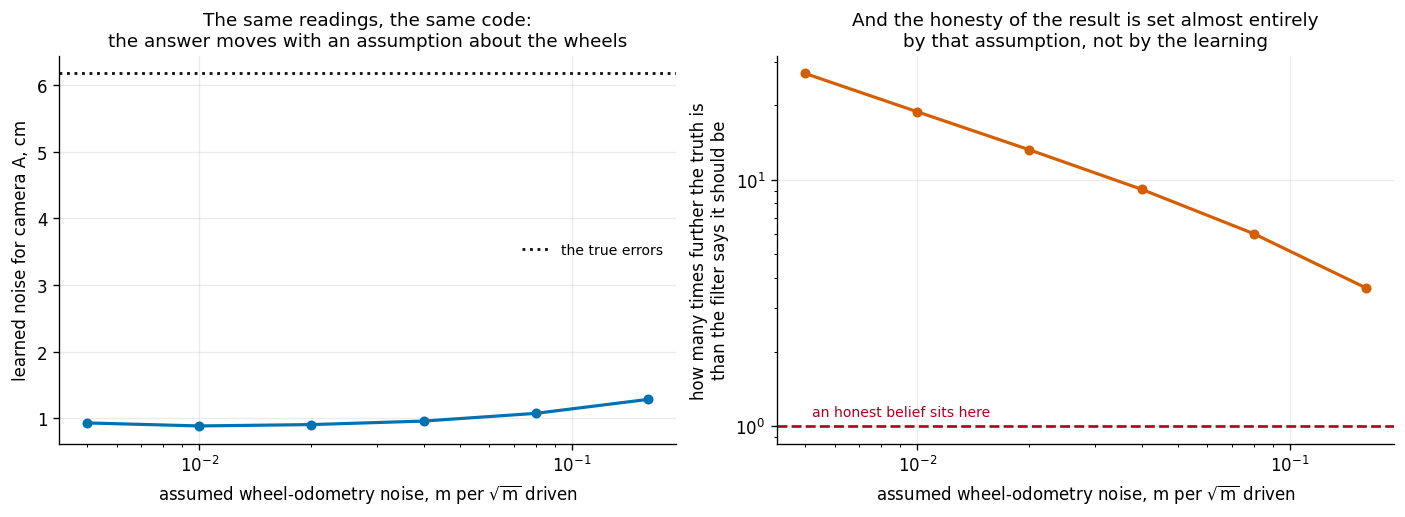

In [32]:
sweep = nm.identifiability_sweep(seq, LEAD, [0.005, 0.01, 0.02, 0.04, 0.08, 0.16])

nv.report_identifiability(sweep)
nv.identifiability(sweep, truth["sigma_total_m"][LEAD], "the true errors", LEAD)

The learned camera noise moves with an assumption about the wheels that the camera data
cannot check — and the honesty of the resulting belief moves far more than the learned
covariance does. The calibration of the final belief is set largely by the assumed
$\mathbf{Q}$, and much less by the $\mathbf{R}$ all this machinery was built to
estimate. Tuning $\mathbf{Q}$ until the belief looks honest is not a fix, though — that
would be fitting a wheel-noise parameter to compensate for a camera lean, on this drive,
against ground truth the robot does not have.

## Do it in the right order

Everything above says the model is wrong about the camera, and it is worth being precise
about *which part* of the model, because the fix follows from that and nothing else.

`oracle_noise` has been returning two covariances all along, and their ratio is the
measurement this notebook has been circling:

$$\underbrace{\mathbf{R}_{\text{total}}}_{\text{about }\mathbf{0}\text{: scatter AND lean}}
\qquad\text{versus}\qquad
\underbrace{\mathbf{R}_{\text{spread}}}_{\text{about the mean: scatter alone}}$$

The first is what a zero-mean model needs. The second is all the loop can see, because
the innovations it is fitted to are taken about a trajectory that has already absorbed
the lean. **The ratio is how much of what the model needs it has no term for**, and no
amount of estimator is going to close it.

So stop trying. A persistent displacement is a statement about **where the camera thinks
the robot is** — the observation function — and that is predictable: project the robot's
own meshes at its pose, take the bottom-centre of the box, back-project. Zero fitted
parameters, heading from odometry, no ground truth. Then ask about the covariance of what
is left.

The comparison below changes *nothing* about the learning loop. It changes only whether
the lean is still in the data when the loop runs.

In [33]:
order = nm.right_order_comparison(seq, models, LEAD)

nv.report_the_right_order(order)

  254 observations were corrected by the mesh model, with heading from odometry.

                                as reported   corrected
  the lean                            8.65        0.46   cm
  sigma a zero-mean model NEEDS        6.17        2.19   cm
  sigma the loop can SEE              0.83        2.17   cm
  sigma the loop LEARNED              0.96        1.25   cm
  needed / visible                    7.4x       1.01x   <- lean the model cannot express

  So the question 'what is this camera's covariance' is not answerable while
  the lean is in the data, and becomes answerable once it is not.

  belief                               NEES  x too sure  RMSE cm
  raw + learned                      115.50        9.1x     8.79
  raw + oracle                        15.35        3.3x     9.43
  corrected + learned                  6.45        2.2x    11.67
  corrected + oracle                   1.14        0.9x     5.15
  corrected + learned + floor          0.40        0.5x     5

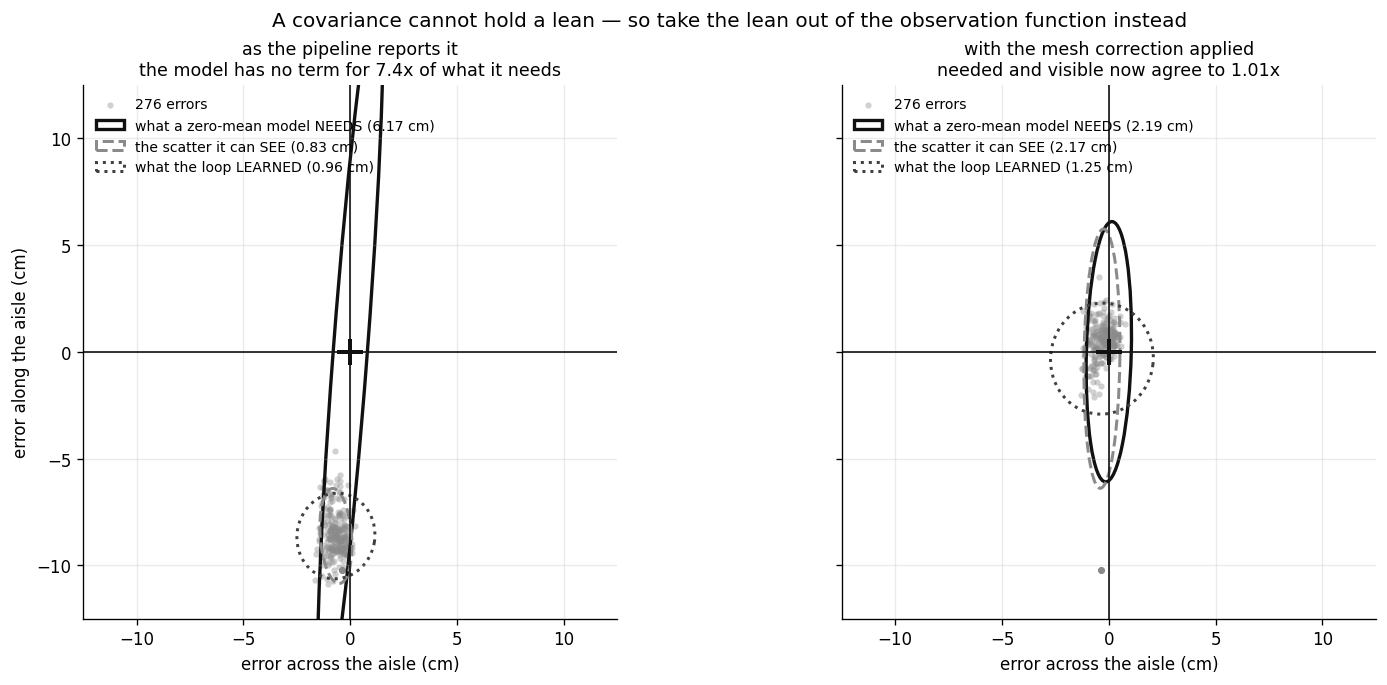

In [34]:
nv.the_lean_leaves_R(seq, order, LEAD)

The ratio goes from about seven to one. That is the whole mechanism, stated as a number:
beforehand the covariance the belief needs is several times the scatter that exists, and
afterwards *they are the same object*. The loop was never estimating the wrong thing — it
was estimating the scatter, correctly, and being asked a question the model could not
express.

But read the arms carefully, because correcting the observation function does **not** on
its own rescue the learned covariance — and the table says so plainly.

**The question becomes well-posed.** Overconfidence falls by more than an order of
magnitude, from ninefold to about twofold, with nothing in the loop changed.

**The answer is still not usable on its own.** The learned covariance is about half the
size the corrected readings need, and this arm has the **worst position error of all
five** — worse than doing nothing about $\mathbf{R}$ at all. Understating $\mathbf{R}$
means over-trusting a camera that still leans slightly, so the belief is dragged onto it.
A well-posed question answered too confidently is still the wrong answer.

**The floor is what closes it, and the loop cannot supply the floor.** The mesh
correction does not remove the displacement entirely — the predictor assumes the whole
robot is visible, and shelving sometimes clips the silhouette — so a residual lean
survives, and a residual lean is a mean rather than a scatter. One isotropic constant
added to $\mathbf{R}$ covers it, and that arm is both honest *and* as accurate as the
ground-truth covariance, to within a millimetre. That constant is fitted, which is the
honest cost of this recipe: **one scalar, on this drive**, and it should be held out
before it is claimed as a method.

Note also what the implied detector noise does — almost nothing, about
$0.4\ \text{px}$ either way. `learn_sigma_px` is fitted to innovations too, so it is
blind to the lean in the same way, which is what makes it a *robust* reading rather than
a contaminated one. It is also far below the $2.5\ \text{px}$ the runtime assumes, while
the total $\mathbf{R}$ that same runtime forms from it is far too small — the assumed
pixel noise is doing a floor's job, badly, because it grows with range and a residual
lean does not.

> **Order of operations:** correct the observation function, *then* learn $\mathbf{R}$,
> *then* floor it. Step one is what makes step two well-posed. Every result earlier in
> this notebook is what step two looks like when step one is skipped.

## Conclusion

**What works.** The update equations are right: the conjugate step is exact, the
variational loop converges in two or three passes, and given data its model describes it
recovers the covariance that generated it. It is also honest about what it does not
know — the posterior over $\mathbf{R}$ narrows exactly as much as the data warrants. The
innovation gate is not what drives the shrinkage either; turning it off barely moves the
answer.

**What does not.** As a way of deciding how much to trust a camera, fitting $\mathbf{R}$
to the drive being filtered asks the filter to trust the camera many times more than its
errors warrant, and makes the belief several times less honest on every drive tested.
What it buys in exchange is real and does not go away when held out — a better forecast
of the camera's next reading, on every drive. That is precisely what makes it dangerous:
the improvement is genuine, it is measurable without ground truth, and it points the
wrong way.

**Why.** This camera does not have zero-mean error. It has a lean — visible in the very
first figure as a few pixels between the bottom of the detector's box and the robot's
actual contact with the floor — and $\mathcal{N}(\mathbf{0}, \mathbf{R})$ has no term
for a lean. Both the fit and the forecast are computed about the filter's own
trajectory, which has already absorbed it, so neither can see the error that matters.
The fit is not wrong about the data; the model is wrong about the camera.

**What to do about it.** A persistent displacement means the **observation function** is
wrong, not that $\mathbf{R}$ is wrong. **No zero-mean noise model can represent it, not
even one handed the right answer**: the first cell of this notebook filtered with the
camera's true error covariance, measured against ground truth on this very drive, and
the belief was still several times too sure. Inflating $\mathbf{R}$ to cover a lean is
the best that model can do, and it is not good enough.

**And that fix is measured here, not deferred.** The last section removes the
displacement with the robot's own meshes — zero fitted parameters, heading from
odometry — and the ratio between what the belief needs and what the loop can see falls
from about sevenfold to one. So the question becomes well-posed. It does **not** become
answered: the same loop, unchanged, still returns a covariance about half the size the
corrected readings need, and that arm has the worst position error of the five. Adding
one isotropic floor for the residual lean the mesh model leaves behind is what produces a
belief that is both honest and as accurate as the ground-truth covariance.

**Decision supported here:** do not deploy a same-drive learned $\mathbf{R}$ as a camera
trust calibration — not on raw readings, and not on corrected readings without a floor.
The recipe with support is **correct the observation function, then learn $\mathbf{R}$,
then floor it**, and the floor is doing more of the work than the learning. What the loop
was measuring all along — the scatter — was never the wrong quantity; it was simply never
the whole of what the belief needed.

**What is not settled by this notebook.** The floor is one scalar fitted on this drive,
and it is load-bearing for the honest arm. The residual lean is largest exactly where
shelving clips the robot's silhouette, and occlusion is not modelled here at all. The
assumed wheel noise $\mathbf{Q}$ is held at its commissioned value throughout, and the
sweep two sections up shows the belief's calibration is more sensitive to that than to
any of this — so these numbers rank choices of $\mathbf{R}$ and are not a final
calibration of anything. And none of it is in the deployed pipeline: this is an offline
study of recorded drives. Notebook 2 defines the displacement precisely in the
four-camera world, where several viewpoints make its geometry visible from more than one
bearing.

---

*Four recorded Gazebo drives in the AWS warehouse, one clock, no synthetic data — the
one cell that generates readings is a labelled self-test of the estimator and no number
from it is quoted. Every estimator is shared through `notebook_model.py` and every
figure through `notebook_views.py`; this notebook defines neither. Ground truth is
evaluation-only.*